# Библиотеки

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import pingouin as pg
import seaborn as sns

## 9.8 Сравнение независимых групп: 2 группы, параметрика

In [2]:
filepath = './data/SPSS_agressor.sav'

d = pd.read_spss(filepath)

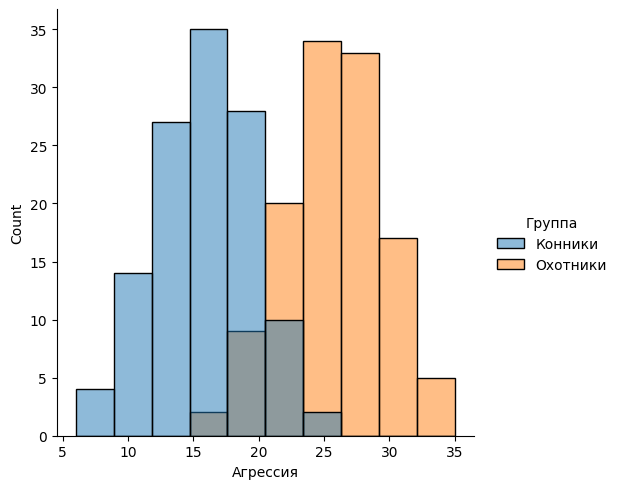

In [3]:
sns.displot(d, x='Агрессия', hue='Группа')

In [4]:
d.groupby('Группа', observed=False).count()

,Агрессия
Группа,
Конники,120
Охотники,120


In [5]:
pd.concat([
    pg.normality(d.loc[d['Группа']=='Конники']).assign(group='Конники'),
    pg.normality(d.loc[d['Группа']=='Охотники']).assign(group='Охотники')
])

,W,pval,normal,group
Агрессия,0.986088,0.256706,True,Конники
Агрессия,0.990116,0.544670,True,Охотники


In [6]:
print(d['Агрессия'].dtype) # смотрим числовой ли ти тип данных
print(d['Агрессия'].unique()) # смотрим много ли уникальных значений, или всего несколько значений  в небольшом диапазоне типа 1-5, 1-7
print(d['Агрессия'].min()) # смотрим минимум и максимум - какой диапазон\размах
print(d['Агрессия'].max()) # смотрим минимум и максимум - какой диапазон\размах
print(d['Группа'].value_counts()) # количество в группах

float64
[20. 15. 19. 17. 14. 16. 12. 18. 13.  7. 21. 10. 24.  8. 22. 11.  9.  6.
 32. 25. 29. 27. 26. 30. 28. 23. 33. 34. 31. 35.]
6.0
35.0
Группа
Конники     120
Охотники    120
Name: count, dtype: int64


In [7]:
pg.normality(data=d,dv='Агрессия', group='Группа') # проверка нормальности ШУ

,W,pval,normal
Группа,,,
Конники,0.986088,0.256706,True
Охотники,0.990116,0.544670,True


In [8]:
pg.normality(data=d,dv='Агрессия', group='Группа', method='jarque_bera') # проверка нормальности ЖБ

,W,pval,normal
Группа,,,
Конники,1.501692,0.471967,True
Охотники,0.727378,0.695107,True


In [9]:
d.groupby('Группа', observed=False).agg(['mean', 'var'])

Агрессия           
               mean        var
Группа                        
Конники   15.708333  14.426821
Охотники  25.933333  15.592157

In [10]:
pg.homoscedasticity(data=d, dv='Агрессия', group='Группа')

,W,pval,equal_var
levene,0.17928,0.672375,True


### ttest

In [11]:
pg.ttest(
    x=d[d['Группа']=='Конники']['Агрессия'],
    y=d[d['Группа']=='Охотники']['Агрессия']
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-20.443535,238,two-sided,2.606290e-54,"[-11.21, -9.24]",2.639249,4.051e+50,1.0


In [12]:
pg.pairwise_tests(
    data=d, dv='Агрессия', between='Группа', parametric=True
)

,Contrast,A,B,Paired,Parametric,T,dof,alternative,p-unc,BF10,hedges
0,Группа,Конники,Охотники,False,True,-20.443535,238.0,two-sided,2.606290e-54,4.051e+50,-2.630923


## 9.10 Сравнение независимых групп: 2 группы, непараметрика

- p-val - значимы (неслучайны) ли различия между "конниками" и "охотниками"

- RBC - насколько сильно группы различаются по рангу (при RBC = 0  группы одинаковы; при RBC > 0 значения первой группы X выше второй Y, а при RBC < 0 наоборот значения первой группы X ниже второй Y)

- CLES - это "размер эффекта". Он показывает вероятность того, что случайно выбранное наблюдение из одной группы Х будет больше, чем случайно выбранное наблюдение из другой группы Y (при CLES ~ 0 значение из группы X <  Y; CLES ~ 0.50 группы неразличимы\одинаковые значения (эффекта нет) X = Y; а CLES ~ 1.00 означает что почти всегда значения из группы Х > Y)

In [13]:
pg.mwu(x=d[d['Группа']=='Конники']['Агрессия'], y=d[d['Группа']=='Охотники']['Агрессия'])

,U-val,alternative,p-val,RBC,CLES
MWU,409.0,two-sided,1.258250e-36,-0.943194,0.028403


## 9.19 Таблицы сопряженности: Хи2 для категориальных признаков, независ

| Статистика            | Суть                                                     | Когда применять |
|----------------------|----------------------------------------------------------|-----------------|
| Pearson              | Классический χ²                                          | Большие ожидаемые частоты |
| Cressie-Read         | Компромисс Pearson и G-test                               | Умеренные перекосы |
| Log-likelihood (G)   | Логарифм правдоподобия                                    | Малые частоты |
| Freeman-Tukey        | Корневая стабилизация дисперсии                           | Сильная неоднородность |
| Mod-log-likelihood   | Скорректированный G-test                                  | Малые выборки |
| Neyman               | Альтернатива Pearson                                      | Используется редко |


На практике обычно используют Pearson, а при малых ожидаемых частотах — log-likelihood или Cressie-Read.



In [31]:
d['AL'] = pd.cut(x=d['Агрессия'], bins=[0, 15, 25, float('inf')], labels=['Н','С','В'], right=True)

In [17]:
d.head(3)

,Группа,Агрессия,AL
0,Конники,20.0,С
1,Конники,15.0,Н
2,Конники,19.0,С


In [28]:
exp, obs, res = pg.chi2_independence(data=d, x='AL', y='Группа')

C:\pyenvs\da-python\Lib\site-packages\pingouin\contingency.py:151: UserWarning: Low count on observed frequencies.
  warnings.warn(f"Low count on {name} frequencies.")
C:\pyenvs\da-python\Lib\site-packages\scipy\stats\_stats_py.py:7409: RuntimeWarning: divide by zero encountered in power
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
C:\pyenvs\da-python\Lib\site-packages\scipy\stats\_stats_py.py:7409: RuntimeWarning: invalid value encountered in multiply
  terms = f_obs * ((f_obs / f_exp)**lambda_ - 1)
C:\pyenvs\da-python\Lib\site-packages\scipy\stats\_stats_py.py:7406: RuntimeWarning: divide by zero encountered in divide
  terms = 2.0 * special.xlogy(f_exp, f_exp / f_obs)


In [30]:
pd.concat([exp.assign(type = 'expected'), obs.assign(type = 'observed')])

Группа,Конники,Охотники,type
AL,,,
Н,28.5,28.5,expected
С,60.0,60.0,expected
В,31.5,31.5,expected
Н,57.0,0.0,observed
С,63.0,57.0,observed
В,0.0,63.0,observed


In [22]:
res

,test,lambda,chi2,dof,pval,cramer,power
0,pearson,1.000000,120.300000,2.0,7.536799e-27,0.707990,1.0
1,cressie-read,0.666667,127.178655,2.0,2.418276e-28,0.727950,1.0
2,log-likelihood,0.000000,166.655448,2.0,6.474842e-37,0.833305,1.0
3,freeman-tukey,-0.500000,NaN,2.0,NaN,NaN,NaN
4,mod-log-likelihood,-1.000000,inf,2.0,0.000000e+00,inf,NaN
5,neyman,-2.000000,NaN,2.0,NaN,NaN,NaN
